# TinyML Context Classifier Training Pipeline

This notebook implements the feature extraction, dataset construction, neural network training, evaluation, data augmentation, and INT8 TFLite quantization pipeline for the SWDP smart glasses context model.

The classifier identifies user environments using AS7341 spectral sensor features and microphone audio features. It is designed to compile to a compact INT8 TFLite model running on resource-constrained microcontrollers.

In [31]:
import json
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import tensorflow as tf
import keras

# Centralized Pipeline Configurations
DRIVE_DATA_DIR = "./data"
OUTPUT_DIR = "./output"
DRIVE_DATA_PATH = Path(DRIVE_DATA_DIR)
DRIVE_FEATURES_PATH = Path(OUTPUT_DIR) / "tinyml_features.csv"
DRIVE_MODEL_DIR = Path(OUTPUT_DIR) / "tinyml_context_model"

SUPPORTED_CONTEXT_LABELS = [
    "UNDERGROUND",
    "OUTDOOR",
    "INDOOR_QUIET",
    "INDOOR_NORMAL",
    "COVERED_DARK",
]

LABEL_ALIASES = {
    "UNDERGROUND_TRANSPORT": "UNDERGROUND",
    "TRANSPORT": "UNDERGROUND",
    "SUBWAY": "UNDERGROUND",
    "METRO": "UNDERGROUND",
    "OUT": "OUTDOOR",
    "OUTSIDE": "OUTDOOR",
    "EXTERNAL": "OUTDOOR",
    "LIBRARY": "INDOOR_QUIET",
    "QUIET": "INDOOR_QUIET",
    "STUDY": "INDOOR_QUIET",
    "IN": "INDOOR_NORMAL",
    "INDOOR": "INDOOR_NORMAL",
    "HOME": "INDOOR_NORMAL",
    "OFFICE": "INDOOR_NORMAL",
    "DRAWER": "COVERED_DARK",
    "BAG": "COVERED_DARK",
    "POCKET": "COVERED_DARK",
    "COVERED": "COVERED_DARK",
    "COVERED_DRAWER": "COVERED_DARK",
}

SPECTRO_CHANNELS = ["F1", "F2", "F3", "F4", "F5", "F6", "F7", "F8", "CLEAR", "NIR"]
DEFAULT_AUDIO_SAMPLE_RATE = 16_000.0
DEFAULT_WINDOW_PACKETS = 9
EMBEDDED_FFT_SIZE = 4096
EPS = 1e-8

LABEL_INDEX_TO_NAME = {
    0: "UNDERGROUND",
    1: "OUTDOOR",
    2: "INDOOR_QUIET",
    3: "INDOOR_NORMAL",
    4: "COVERED_DARK",
}

print("Libraries loaded and paths initialized.")
print(f"TensorFlow version: {tf.__version__}")

Libraries loaded and paths initialized.
TensorFlow version: 2.21.0


## 1. Data Representation and IO Utilities

This cell defines the core `Recording` class and utility functions for labels decoding and loading files from the dataset.

In [32]:
@dataclass(frozen=True)
class Recording:
    path: Path
    recording_id: str
    label: str
    audio: np.ndarray
    spectro: np.ndarray
    flicker: np.ndarray
    audio_sample_rate: float


def canonical_label(raw_label: Any) -> str:
    if isinstance(raw_label, bytes):
        raw_label = raw_label.decode("utf-8")
    if isinstance(raw_label, (int, np.integer)):
        if int(raw_label) not in LABEL_INDEX_TO_NAME:
            raise ValueError(f"Unknown numeric label '{raw_label}'. Expected one of: {LABEL_INDEX_TO_NAME}")
        return LABEL_INDEX_TO_NAME[int(raw_label)]

    label = str(raw_label).strip().upper().replace(" ", "_").replace("-", "_")
    if label.lstrip("+-").isdigit():
        label_index = int(label)
        if label_index not in LABEL_INDEX_TO_NAME:
            raise ValueError(f"Unknown numeric label '{raw_label}'. Expected one of: {LABEL_INDEX_TO_NAME}")
        return LABEL_INDEX_TO_NAME[label_index]

    label = LABEL_ALIASES.get(label, label)
    if label not in SUPPORTED_CONTEXT_LABELS:
        allowed = ", ".join(SUPPORTED_CONTEXT_LABELS)
        raise ValueError(f"Unknown label '{raw_label}'. Expected one of: {allowed}")
    return label


def scalar_from_npz(data: Any, key: str, default: Any = None) -> Any:
    if key not in data.files:
        return default
    value = data[key]
    if np.asarray(value).shape == ():
        return value.item()
    return np.asarray(value).reshape(-1)[0].item()


def read_label(data: Any, path: Path) -> str:
    if "label" in data.files:
        values = np.asarray(data["label"]).reshape(-1)
        unique = sorted({canonical_label(value) for value in values})
        if len(unique) != 1:
            raise ValueError(f"{path.name}: expected one label per recording, found {unique}")
        return unique[0]
    if "labels" in data.files:
        labels = np.asarray(data["labels"]).reshape(-1)
        unique = sorted({canonical_label(value) for value in labels})
        if len(unique) != 1:
            raise ValueError(f"{path.name}: expected one label per recording, found {unique}")
        return unique[0]
    raise ValueError(f"{path.name}: missing 'label' or 'labels' field")


def read_recording(path: Path) -> Recording:
    with np.load(path, allow_pickle=True) as data:
        if "audio" not in data.files:
            raise ValueError(f"{path.name}: missing required 'audio' array")
        if "spectro" not in data.files:
            raise ValueError(f"{path.name}: missing required 'spectro' array")

        audio = np.asarray(data["audio"])
        spectro = np.asarray(data["spectro"], dtype=np.float32)
        flicker = np.asarray(data["flicker"], dtype=np.float32).reshape(-1) if "flicker" in data.files else None
        label = read_label(data, path)

        if audio.ndim != 2:
            raise ValueError(f"{path.name}: 'audio' must have shape (packets, samples)")
        if spectro.ndim != 2 or spectro.shape[1] != len(SPECTRO_CHANNELS):
            raise ValueError(f"{path.name}: 'spectro' must have shape (packets, 10)")
        if spectro.shape[0] != audio.shape[0]:
            raise ValueError(f"{path.name}: audio and spectro packet counts do not match")
        if flicker is None:
            flicker = np.zeros(audio.shape[0], dtype=np.float32)
        if flicker.shape[0] != audio.shape[0]:
            raise ValueError(f"{path.name}: flicker and audio packet counts do not match")

        audio_sample_rate = float(scalar_from_npz(data, "audio_sample_rate", DEFAULT_AUDIO_SAMPLE_RATE))

    return Recording(
        path=path,
        recording_id=path.stem,
        label=label,
        audio=audio.astype(np.float32),
        spectro=spectro,
        flicker=flicker.astype(np.float32),
        audio_sample_rate=audio_sample_rate,
    )


def npz_files(data_dir: Path) -> list[Path]:
    return sorted(path for path in data_dir.glob("*.npz") if path.is_file())


def save_json(path: Path, payload: dict[str, Any]) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

## 2. Firmware-Equivalent Feature Extraction

This section implements the window-level feature extraction. The processing is mathematically identical to the C-firmware feature computation logic, extracting:
- **Audio features**: RMS, abs mean, zero-crossing rate, crest factor, spectral centroid, and power spectral bands (low, mid, high, very high) based on 8192-point Hann-windowed FFTs.
- **Spectral sensor features**: total intensity, clear intensity, ratios of NIR to clear, blue/green/red ratios, dark fraction, and saturation indicator.
- **Flicker sensor features**: fractions of detected flickering frequencies (100Hz and 120Hz).

In [33]:
def safe_ratio(num: np.ndarray | float, den: np.ndarray | float) -> np.ndarray | float:
    return np.asarray(num) / (np.asarray(den) + EPS)


def embedded_audio_spectrum_features(signal: np.ndarray, sample_rate: float) -> tuple[dict[str, float], float]:
    if signal.size == 0:
        signal = np.zeros(1, dtype=np.float32)

    fft_size = EMBEDDED_FFT_SIZE
    hann = np.hanning(fft_size).astype(np.float32)
    freqs = np.fft.rfftfreq(fft_size, d=1.0 / sample_rate)

    bands = {
        "low": 0.0,
        "mid": 0.0,
        "high": 0.0,
        "very_high": 0.0,
    }
    centroid_num = 0.0
    centroid_den = 0.0

    for start in range(0, signal.size, fft_size):
        block = signal[start : start + fft_size]
        if block.size < fft_size:
            padded = np.zeros(fft_size, dtype=np.float32)
            padded[: block.size] = block
            block = padded

        spectrum = np.fft.rfft(block * hann)
        power = (spectrum.real * spectrum.real) + (spectrum.imag * spectrum.imag)
        magnitude = np.sqrt(power) + EPS

        bands["low"] += float(power[(freqs >= 20.0) & (freqs < 250.0)].sum())
        bands["mid"] += float(power[(freqs >= 250.0) & (freqs < 1000.0)].sum())
        bands["high"] += float(power[(freqs >= 1000.0) & (freqs < 4000.0)].sum())
        bands["very_high"] += float(power[(freqs >= 4000.0) & (freqs < 7900.0)].sum())

        centroid_num += float((freqs * magnitude).sum())
        centroid_den += float(magnitude.sum())

    centroid = centroid_num / (centroid_den + EPS)
    return bands, float(centroid)


def extract_spectro_features(spectro_window: np.ndarray) -> dict[str, float]:
    visible = spectro_window[:, :8]
    clear = spectro_window[:, 8]
    nir = spectro_window[:, 9]
    channel_means = spectro_window.mean(axis=0)
    clear_mean = float(clear.mean())
    visible_sum = visible.sum(axis=1)
    visible_mean = float(visible_sum.mean())

    features: dict[str, float] = {
        "lumos_total_log": float(np.log1p(spectro_window.sum(axis=1).mean())),
        "lumos_clear_log": float(np.log1p(clear_mean)),
        "lumos_nir_clear_ratio": float(safe_ratio(nir.mean(), clear_mean)),
        "lumos_clear_std_ratio": float(safe_ratio(clear.std(), clear_mean)),
        "lumos_visible_std_ratio": float(safe_ratio(visible_sum.std(), visible_mean)),
        "lumos_blue_red_ratio": float(safe_ratio(channel_means[0] + channel_means[1], channel_means[6] + channel_means[7])),
        "lumos_green_red_ratio": float(safe_ratio(channel_means[3] + channel_means[4], channel_means[6] + channel_means[7])),
        "lumos_dark_fraction": float(np.mean((clear < 10.0) & (visible_sum < 80.0))),
        "lumos_saturation_fraction": float(np.mean(spectro_window >= 65000.0)),
    }

    for idx, name in enumerate(SPECTRO_CHANNELS[:8]):
        features[f"lumos_{name.lower()}_clear_ratio"] = float(safe_ratio(channel_means[idx], clear_mean))

    return features


def extract_audio_features(audio_window: np.ndarray, sample_rate: float) -> dict[str, float]:
    x = audio_window.astype(np.float32).reshape(-1) / 32768.0
    if x.size == 0:
        x = np.zeros(1, dtype=np.float32)
    abs_x = np.abs(x)
    rms = float(np.sqrt(np.mean(x * x)))
    peak = float(abs_x.max())
    zc = float(np.mean(np.diff(np.signbit(x)) != 0)) if x.size > 1 else 0.0

    bands, centroid = embedded_audio_spectrum_features(x, sample_rate)
    total_band_energy = sum(bands.values()) + EPS

    features = {
        "audio_rms": rms,
        "audio_log_energy": float(np.log1p(np.mean(x * x))),
        "audio_abs_mean": float(abs_x.mean()),
        "audio_std": float(x.std()),
        "audio_peak": peak,
        "audio_crest_factor": float(peak / (rms + EPS)),
        "audio_silence_fraction": float(np.mean(abs_x < 0.005)),
        "audio_zero_crossing_rate": zc,
        "audio_low_high_ratio": float((bands["low"] + EPS) / (bands["high"] + bands["very_high"] + EPS)),
        "audio_spectral_centroid_hz": centroid,
    }

    for name, value in bands.items():
        features[f"audio_{name}_band_log"] = float(np.log1p(value))
        features[f"audio_{name}_band_ratio"] = float(value / total_band_energy)

    return features


def extract_flicker_features(flicker_window: np.ndarray) -> dict[str, float]:
    values = flicker_window.astype(np.float32).reshape(-1)
    if values.size == 0:
        values = np.zeros(1, dtype=np.float32)
    known = np.isin(values, [0.0, 1.0, 2.0, 3.0])
    return {
        "flicker_sensor_off_fraction": float(np.mean(values == 0.0)),
        "flicker_none_fraction": float(np.mean(values == 1.0)),
        "flicker_100hz_fraction": float(np.mean(values == 2.0)),
        "flicker_120hz_fraction": float(np.mean(values == 3.0)),
        "flicker_detected_fraction": float(np.mean((values == 2.0) | (values == 3.0))),
        "flicker_unknown_fraction": float(np.mean(~known)),
    }


def extract_recording_features(recording: Recording, window_packets: int) -> list[dict[str, Any]]:
    packet_duration = recording.audio.shape[1] / recording.audio_sample_rate
    window_packets = max(1, int(window_packets))
    rows: list[dict[str, Any]] = []

    for start in range(0, recording.audio.shape[0] - window_packets + 1, window_packets):
        end = start + window_packets
        row: dict[str, Any] = {
            "recording_id": recording.recording_id,
            "source_file": recording.path.name,
            "label": recording.label,
            "window_start_packet": start,
            "window_end_packet": end,
            "window_start_s": round(start * packet_duration, 3),
            "window_end_s": round(end * packet_duration, 3),
        }
        row.update(extract_spectro_features(recording.spectro[start:end]))
        row.update(extract_flicker_features(recording.flicker[start:end]))
        row.update(extract_audio_features(recording.audio[start:end], recording.audio_sample_rate))
        rows.append(row)

    return rows

## 3. Dataset Construction

This section builds the context model dataset by reading all raw `.npz` recordings, running the feature extractors, assembling the features into a Pandas DataFrame, saving to CSV, and dumping metadata.

In [34]:
def feature_columns(df: pd.DataFrame) -> list[str]:
    excluded = {"recording_id", "source_file", "label", "window_start_packet", "window_end_packet", "window_start_s", "window_end_s"}
    return [col for col in df.columns if col not in excluded]


def observed_labels_in_order(labels: Iterable[str]) -> list[str]:
    present = set(labels)
    ordered = [label for label in SUPPORTED_CONTEXT_LABELS if label in present]
    extras = sorted(present.difference(SUPPORTED_CONTEXT_LABELS))
    return ordered + extras


def build_features(
    data_dir: Path = DRIVE_DATA_PATH,
    out: Path = DRIVE_FEATURES_PATH,
    window_packets: int = DEFAULT_WINDOW_PACKETS,
    skip_bad_files: bool = False
) -> pd.DataFrame:
    files = npz_files(data_dir)
    if not files:
        raise FileNotFoundError(f"No .npz files found in {data_dir}")

    rows: list[dict[str, Any]] = []
    errors: list[str] = []
    for path in files:
        try:
            rows.extend(extract_recording_features(read_recording(path), window_packets))
        except Exception as exc:
            errors.append(f"{path.name}: {exc}")

    if errors and not skip_bad_files:
        raise RuntimeError("Feature extraction failed:\n" + "\n".join(errors))
    if not rows:
        raise RuntimeError("No feature rows were generated")

    out.parent.mkdir(parents=True, exist_ok=True)
    df = pd.DataFrame(rows)
    df.to_csv(out, index=False)

    metadata = {
        "supported_labels": SUPPORTED_CONTEXT_LABELS,
        "label_index_to_name": LABEL_INDEX_TO_NAME,
        "observed_labels": observed_labels_in_order(df["label"].unique()),
        "window_packets": window_packets,
        "feature_columns": feature_columns(df),
        "rows": int(len(df)),
        "recordings": int(df["recording_id"].nunique()),
        "class_counts": df["label"].value_counts().to_dict(),
        "sensors": ["spectro", "flicker", "audio"],
        "errors_skipped": errors,
    }
    out.with_suffix(".metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    print(f"SUCCESS: Wrote {len(df)} feature windows to {out}")
    print(f"Class counts: {metadata['class_counts']}")
    if errors:
        print(f"Skipped {len(errors)} bad files; see metadata JSON.")
    return df


# Construct the dataset
df_features = build_features(DRIVE_DATA_PATH, DRIVE_FEATURES_PATH, DEFAULT_WINDOW_PACKETS, skip_bad_files=True)

SUCCESS: Wrote 1178 feature windows to output/tinyml_features.csv
Class counts: {'INDOOR_NORMAL': 412, 'OUTDOOR': 333, 'INDOOR_QUIET': 236, 'COVERED_DARK': 112, 'UNDERGROUND': 85}


## 4. Preprocessing and Splitting

This section structures the feature variables, splits the dataset, and scales feature inputs:
- Splits the dataset into train and test groups using `GroupShuffleSplit` (grouped by `recording_id`) to ensure there is no data leakage across recording sessions, falling back to a stratified `train_test_split` if classes lack sufficient recordings.
- Applies standard Z-score normalization (`(X - mean) / std`) calculated from the train dataset.

In [35]:
def class_weight_dict(y_indices: np.ndarray) -> dict[int, float]:
    present = np.unique(y_indices)
    weights = compute_class_weight(class_weight="balanced", classes=present, y=y_indices)
    return {int(cls): float(weight) for cls, weight in zip(present, weights)}


def split_dataset(
    df: pd.DataFrame,
    y: np.ndarray,
    test_size: float = 0.2,
    random_state: int = 42,
) -> tuple[np.ndarray, np.ndarray, str, str | None]:
    labels = set(df["label"])
    recordings_per_label = df.groupby("label")["recording_id"].nunique()

    if len(df["recording_id"].unique()) >= 2 and recordings_per_label.min() >= 2:
        groups = df["recording_id"].to_numpy()
        splitter = GroupShuffleSplit(n_splits=100, test_size=test_size, random_state=random_state)
        for train_idx, test_idx in splitter.split(df, y, groups):
            if set(df.iloc[train_idx]["label"]) == labels and set(df.iloc[test_idx]["label"]) == labels:
                return train_idx, test_idx, "GroupShuffleSplit by recording_id", None

    warning = (
        "Only one recording is available for at least one class, so the split falls back to "
        "stratified windows. This verifies the pipeline, but it is not a robust scientific "
        "generalization test."
    )
    indices = np.arange(len(df))
    train_idx, test_idx = train_test_split(
        indices,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )
    return train_idx, test_idx, "Stratified train_test_split by window", warning


columns = feature_columns(df_features)
labels = observed_labels_in_order(df_features["label"].unique())
label_to_index = {label: idx for idx, label in enumerate(labels)}
y = df_features["label"].map(label_to_index).to_numpy(dtype=np.int64)
x = df_features[columns].to_numpy(dtype=np.float32)

train_idx, test_idx, split_strategy, split_warning = split_dataset(df_features, y, test_size=0.2, random_state=42)
x_train_raw, x_test_raw = x[train_idx], x[test_idx]
y_train_raw, y_test = y[train_idx], y[test_idx]

if split_warning:
    print(f"WARNING: {split_warning}")
print(f"Split Strategy: {split_strategy}")
print(f"Train set shape: {x_train_raw.shape}, Test set shape: {x_test_raw.shape}")

# Compute scale stats and normalize
mean = x_train_raw.mean(axis=0)
std = x_train_raw.std(axis=0)
std[std < 1e-6] = 1.0
x_train_scaled = (x_train_raw - mean) / std
x_test_scaled = (x_test_raw - mean) / std

Split Strategy: Stratified train_test_split by window
Train set shape: (942, 41), Test set shape: (236, 41)


## 5. Tabular Data Augmentation: Feature Jittering

To prevent overfitting on limited sessions and improve robustness to sensor noise in embedded deployment, we augment the training dataset by adding small random Gaussian noise ($N(0, \sigma^2)$) to the scaled training features. We multiply the size of the training split while leaving the evaluation test split untouched.

In [36]:
def augment_features(x_train: np.ndarray, y_train: np.ndarray, noise_level: float = 0.05, augmentation_factor: int = 3) -> tuple[np.ndarray, np.ndarray]:
    """Applies Gaussian noise injection (jittering) to the training features."""
    x_aug_list = [x_train]
    y_aug_list = [y_train]
    for _ in range(augmentation_factor - 1):
        noise = np.random.normal(0.0, noise_level, x_train.shape)
        x_aug_list.append(x_train + noise)
        y_aug_list.append(y_train)
    return np.concatenate(x_aug_list, axis=0), np.concatenate(y_aug_list, axis=0)


# Split into sub-train and validation sets first to avoid data leakage during validation split of augmented data
x_train_sub, x_val, y_train_sub, y_val = train_test_split(
    x_train_scaled,
    y_train_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_train_raw,
)

# Apply data augmentation only to the training subset
x_train, y_train = augment_features(x_train_sub, y_train_sub, noise_level=0.05, augmentation_factor=3)
print(f"Sub-train shape: {x_train_sub.shape}, Validation shape: {x_val.shape}")
print(f"Augmented Train set shape: {x_train.shape} (from {x_train_sub.shape})")

Sub-train shape: (753, 41), Validation shape: (189, 41)
Augmented Train set shape: (2259, 41) (from (753, 41))


## 6. Model Definition and Training

This section builds a sequential MLP model matching hardware limitations, and fits the weights using Keras with class weight balancing.

In [37]:
# Set random seeds for reproducibility
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

def build_model(input_dim: int, num_classes: int):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,), name="context_features"),
        keras.layers.Dense(32, activation="relu", name="dense_32"),
        keras.layers.Dense(16, activation="relu", name="dense_16"),
        keras.layers.Dense(num_classes, activation="softmax", name="context_probs"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_model(input_dim=x_train.shape[1], num_classes=len(labels))
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
    )
]

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=120,
    batch_size=16,
    callbacks=callbacks,
    class_weight=class_weight_dict(y_train),
    verbose=1,
)

Epoch 1/120


E0000 00:00:1781886937.002762  654207 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6481 - loss: 0.8637 - val_accuracy: 0.9206 - val_loss: 0.4443
Epoch 2/120
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step - accuracy: 0.9385 - loss: 0.1994 - val_accuracy: 0.9683 - val_loss: 0.1298
Epoch 3/120
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - accuracy: 0.9584 - loss: 0.0996 - val_accuracy: 0.9788 - val_loss: 0.0839
Epoch 4/120
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - accuracy: 0.9650 - loss: 0.0682 - val_accuracy: 0.9788 - val_loss: 0.0688
Epoch 5/120
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - accuracy: 0.9761 - loss: 0.0506 - val_accuracy: 0.9841 - val_loss: 0.0629
Epoch 6/120
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - accuracy: 0.9819 - loss: 0.0373 - val_accuracy: 0.9841 - val_loss: 0.0598
Epoch 7/120
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step - accuracy: 0.9876 - loss: 0.0281 - val_accuracy: 0.9841 - val_loss: 0.0563
Epoch 8/120
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - accuracy: 0.9894 - loss: 0.0215 - val_ac

## 7. Floating-Point Keras Model Evaluation

Evaluates classification predictions on the validation/test partition using the baseline floating-point Keras model, displaying accuracy, Macro F1, and standard scores.

In [38]:
pred_prob = model.predict(x_test_scaled, verbose=0)
keras_pred = np.argmax(pred_prob, axis=1)

keras_accuracy = float(accuracy_score(y_test, keras_pred))
keras_f1 = float(f1_score(y_test, keras_pred, average="macro", zero_division=0))

print("=== FLOAT KERAS MODEL EVALUATION ===")
print(f"Accuracy: {keras_accuracy:.4f}")
print(f"Macro F1: {keras_f1:.4f}")
print(classification_report(y_test, keras_pred, target_names=labels, zero_division=0))

=== FLOAT KERAS MODEL EVALUATION ===
Accuracy: 1.0000
Macro F1: 1.0000
               precision    recall  f1-score   support

  UNDERGROUND       1.00      1.00      1.00        17
      OUTDOOR       1.00      1.00      1.00        67
 INDOOR_QUIET       1.00      1.00      1.00        47
INDOOR_NORMAL       1.00      1.00      1.00        83
 COVERED_DARK       1.00      1.00      1.00        22

     accuracy                           1.00       236
    macro avg       1.00      1.00      1.00       236
 weighted avg       1.00      1.00      1.00       236



## 8. INT8 Quantization and TFLite Model Evaluation

Quantizes the Keras model parameters down to 8-bit integers (INT8) through Post-Training Quantization (PTQ) with a representative dataset generator to calibrate scales and zero-points. Then, executes inference on the test set partition using the quantized model via the TFLite Interpreter to compute its corresponding score.

In [39]:
def export_int8_tflite(model: Any, representative_x: np.ndarray, out_path: Path) -> dict[str, Any]:
    def representative_dataset() -> Iterable[list[np.ndarray]]:
        count = min(100, representative_x.shape[0])
        for idx in range(count):
            yield [representative_x[idx : idx + 1].astype(np.float32)]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    tflite_model = converter.convert()
    out_path.write_bytes(tflite_model)

    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    return {
        "path": str(out_path),
        "size_bytes": len(tflite_model),
        "input_shape": [int(x) for x in input_details["shape"]],
        "output_shape": [int(x) for x in output_details["shape"]],
        "input_quantization": {
            "scale": float(input_details["quantization"][0]),
            "zero_point": int(input_details["quantization"][1]),
            "dtype": str(input_details["dtype"]),
        },
        "output_quantization": {
            "scale": float(output_details["quantization"][0]),
            "zero_point": int(output_details["quantization"][1]),
            "dtype": str(output_details["dtype"]),
        },
    }


def evaluate_tflite(tflite_path: Path, x_eval: np.ndarray) -> np.ndarray:
    interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    
    in_scale, in_zero = input_details["quantization"]
    
    predictions = []
    for idx in range(len(x_eval)):
        sample_x = x_eval[idx : idx + 1]
        if input_details["dtype"] == np.int8:
            model_input = np.clip(np.round(sample_x / in_scale + in_zero), -128, 127).astype(np.int8)
        else:
            model_input = sample_x.astype(input_details["dtype"])
            
        interpreter.set_tensor(input_details["index"], model_input)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])
        predictions.append(np.argmax(output.reshape(-1)))
        
    return np.array(predictions, dtype=np.int64)


DRIVE_MODEL_DIR.mkdir(parents=True, exist_ok=True)
tflite_path = DRIVE_MODEL_DIR / "tinyml_context_model_int8.tflite"
tflite_info = export_int8_tflite(model, x_train_scaled, tflite_path)
tflite_pred = evaluate_tflite(tflite_path, x_test_scaled)

tflite_accuracy = float(accuracy_score(y_test, tflite_pred))
tflite_f1 = float(f1_score(y_test, tflite_pred, average="macro", zero_division=0))

print("=== QUANTIZED INT8 TFLITE MODEL EVALUATION ===")
print(f"TFLite Size: {tflite_info['size_bytes']} bytes")
print(f"Accuracy: {tflite_accuracy:.4f} (Float was: {keras_accuracy:.4f})")
print(f"Macro F1: {tflite_f1:.4f} (Float was: {keras_f1:.4f})")
print(classification_report(y_test, tflite_pred, target_names=labels, zero_division=0))

# Save Metadata files for deployment compatibility
model.save(DRIVE_MODEL_DIR / "keras_model.keras")
metadata = {
    "supported_labels": SUPPORTED_CONTEXT_LABELS,
    "labels": labels,
    "feature_columns": columns,
    "normalization": {
        "mean": {col: float(value) for col, value in zip(columns, mean)},
        "std": {col: float(value) for col, value in zip(columns, std)},
    },
    "windowing": {
        "window_packets": DEFAULT_WINDOW_PACKETS,
        "split": split_strategy,
        "split_warning": split_warning,
    },
    "model": {
        "architecture": ["Dense(32, relu)", "Dense(16, relu)", f"Dense({len(labels)}, softmax)"],
        "input_dim": int(x_train_scaled.shape[1]),
        "output_dim": len(labels),
        "sensors": ["spectro", "flicker", "audio"],
    },
    "metrics": {
        "accuracy": tflite_accuracy,
        "macro_f1": tflite_f1,
    },
    "tflite": tflite_info,
}
save_json(DRIVE_MODEL_DIR / "model_metadata.json", metadata)
save_json(DRIVE_MODEL_DIR / "labels.json", {"labels": labels, "label_to_index": label_to_index})
save_json(DRIVE_MODEL_DIR / "feature_normalization.json", metadata["normalization"])
save_json(DRIVE_MODEL_DIR / "feature_columns.json", {"feature_columns": columns})

INFO:tensorflow:Assets written to: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpsusbww73/assets


INFO:tensorflow:Assets written to: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpsusbww73/assets


Saved artifact at '/var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpsusbww73'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 41), dtype=tf.float32, name='context_features')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  4859856272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4859857232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4859858192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4859870672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4859859728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4859868368: TensorSpec(shape=(), dtype=tf.resource, name=None)


/Users/mirko/Developer/SWDPProject/pipeline/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1781886941.253597  654207 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.


=== QUANTIZED INT8 TFLITE MODEL EVALUATION ===
TFLite Size: 6000 bytes
Accuracy: 1.0000 (Float was: 1.0000)
Macro F1: 1.0000 (Float was: 1.0000)
               precision    recall  f1-score   support

  UNDERGROUND       1.00      1.00      1.00        17
      OUTDOOR       1.00      1.00      1.00        67
 INDOOR_QUIET       1.00      1.00      1.00        47
INDOOR_NORMAL       1.00      1.00      1.00        83
 COVERED_DARK       1.00      1.00      1.00        22

     accuracy                           1.00       236
    macro avg       1.00      1.00      1.00       236
 weighted avg       1.00      1.00      1.00       236



W0000 00:00:1781886941.253611  654207 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1781886941.254391  654207 reader.cc:83] Reading SavedModel from: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpsusbww73
I0000 00:00:1781886941.254726  654207 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1781886941.254731  654207 reader.cc:147] Reading SavedModel debug info (if present) from: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpsusbww73
I0000 00:00:1781886941.257956  654207 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1781886941.272529  654207 loader.cc:220] Running initialization op on SavedModel bundle at path: /var/folders/p8/f0ql1fmx0yqbsmkfmx969hpm0000gn/T/tmpsusbww73
I0000 00:00:1781886941.276941  654207 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 22554 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1781886941

## 9. Performance Comparison: Confusion Matrices

This section displays a side-by-side comparison of the confusion matrices calculated on the test dataset partition for both the float Keras model and the quantized INT8 TFLite model.

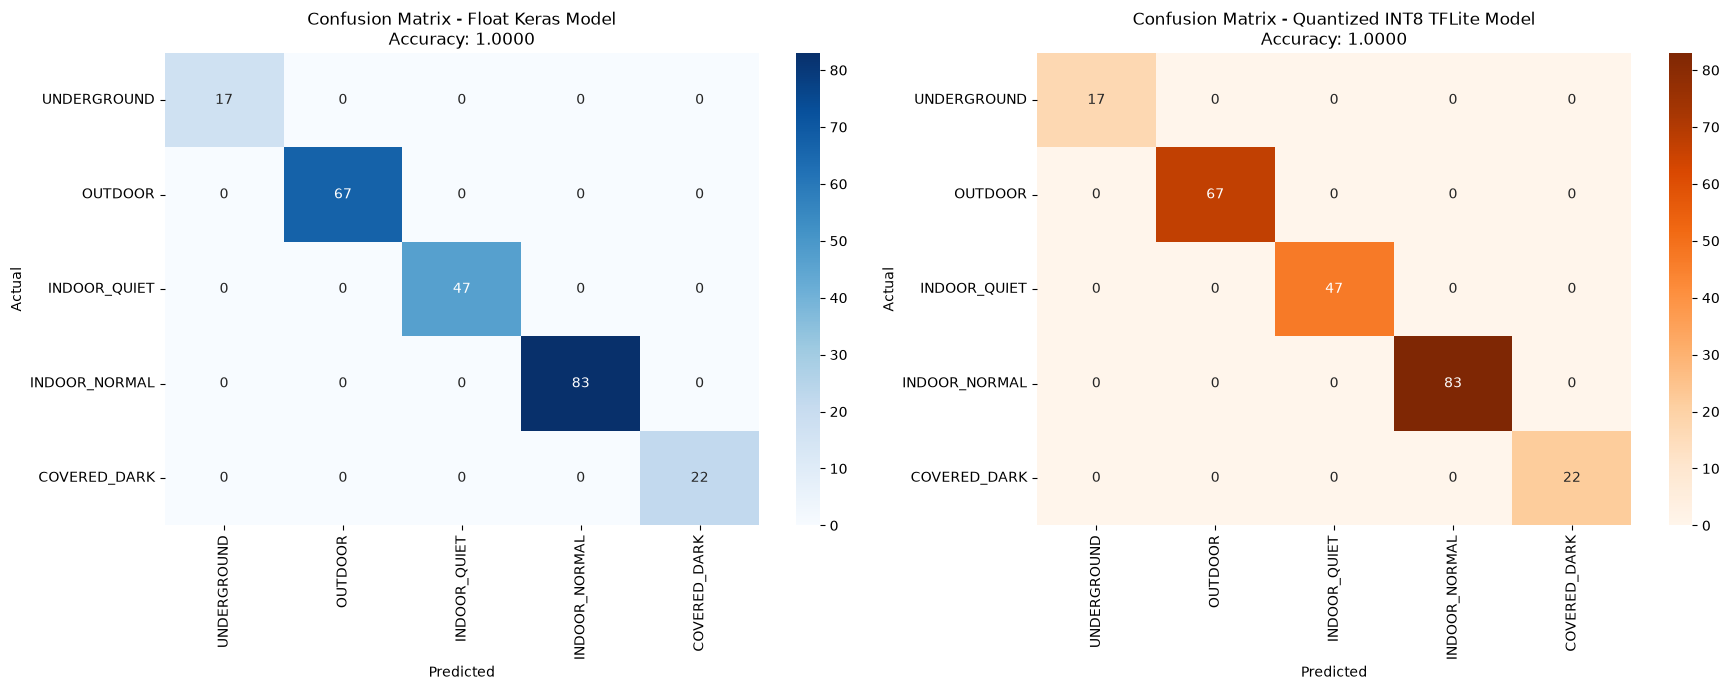

In [40]:
cm_keras = confusion_matrix(y_test, keras_pred)
cm_tflite = confusion_matrix(y_test, tflite_pred)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Keras Confusion Matrix
sns.heatmap(cm_keras, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f"Confusion Matrix - Float Keras Model\nAccuracy: {keras_accuracy:.4f}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# TFLite Confusion Matrix
sns.heatmap(cm_tflite, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f"Confusion Matrix - Quantized INT8 TFLite Model\nAccuracy: {tflite_accuracy:.4f}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()